## Barotropic streamfunction panan-rOM3 analysis notebook

For `8km_jra_ryf_obc_Charrassin` experiment (MOM6-CICE6 panan 1/12th degree ~ 4km with no ice shelves)

**Note** Several non-standard uses of `esm_datastore`:

- `esm_datastore` was generated with a different branch to main to pick up incorrectly named files (see https://github.com/ACCESS-NRI/access-nri-intake-catalog/issues/459, thanks to Charles Turner for fixing this for me)
- Years 9 and 10 of this run used parallelised IO, and unfortunately the tiling resulted in NaNs along part of the y axis in these files. Therefore, we must use a preprocessing function that replaces these axes with that of an earlier time (month 0) (thanks to Jemma Jeffree for her help with this!)



Note that this notebook is based on the [Barotrophic streamfunction cosima-recipe](https://github.com/COSIMA/cosima-recipes/blob/main/Recipes/Appetisers-Easy/Barotropic_Streamfunction.ipynb) #f009c847e8e9067e0ad9068e603058ebfc104dd7 

# Barotropic Streamfunction Calculation

The barotropic streamfunction ($\psi$) is obtained from the integration of the velocity field starting from a physical boundary at which we know the transport is zero. The difference between to streamlines is a measure of the transport between them. 

There are different ways to calculate it depending on your choice of boundary for the integration. This notebook calculates it integrating in the meridional space, starting from the Antarctic continent using the zonal velocity field:

$$
\psi = \int_{y_{\rm Antarctica}}^{y} U \, \mathrm{d}y ,
$$

where $U = \int u \, \mathrm{dz}$ is the depth-integrated $u$-velocity.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client
import intake

import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg

import matplotlib.path as mpath
import cartopy.crs as ccrs
import cmocean

import dask.distributed as dask
import warnings
import intake
warnings.simplefilter(action = 'ignore', category = UserWarning)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
client = Client(threads_per_worker = 1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46535,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37865,Total threads: 1
Dashboard: /proxy/42721/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:39401,


### Load datastore for panant-rom3

In [3]:
esm_datastore = intake.open_esm_datastore(
    "/g/data/ol01/cy8964/access-om3/archive/8km_jra_ryf_obc_Charrassin/experiment_datastore.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)



### Load month 0 specific datastore to get y axis info

In [4]:
mo0_esm_datastore = intake.open_esm_datastore(
    "/g/data/ol01/cy8964/access-om3/datastores/8km_jra_ryf_obc_Charrassin-output000/experiment_datastore.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)

ds_good_yh = mo0_esm_datastore.search(variable="umo_2d").to_dask(xarray_open_kwargs={'decode_timedelta':True})
good_yh_coords = ds_good_yh.yh.copy().load()
ds_good_yq = mo0_esm_datastore.search(variable="vmo_2d").to_dask(xarray_open_kwargs={'decode_timedelta':True})
good_yq_coords = ds_good_yq.yq.copy().load()
def reset_y_coords(ds): #thanks to Jemma Jeffree for helping make this work!!
    ds = ds.assign_coords({'yh':good_yh_coords})
    ds = ds.assign_coords({'yq':good_yq_coords})
    return ds

In [5]:
#load catalogue for other models
cat = intake.cat.access_nri

In [6]:
model_args = {
              "panant-01": {"expt": "panant-01-zstar-ACCESSyr2",
                       "data_var": "umo_2d",
                       "bathy_var": "deptho",
                       "start_date": "203[5-9].*|204[0-9].*",
                       "frequency" : "1mon",
                       "in_accesscat" : True,

             },
              "panant-005": {"expt": "panant-005-zstar-ACCESSyr2",
                       "data_var": "umo_2d",
                       "bathy_var": "deptho",
                       "start_date": "203[5-9].*|204[0-9].*",
                       "frequency" : "1mon",
                       "in_accesscat" : True,
 
              },
               "panant-0025": {"expt": "panant-0025-zstar-ACCESSyr2",
                       "data_var": "umo_2d",
                       "bathy_var": "deptho",
                       "start_date": "203[5-9].*|204[0-9].*",
                       "frequency" : "1mon",
                       "in_accesscat" : True,
 
              },
              "panant-rom3": {"expt": " ",
                       "data_var": "umo_2d",
                       "bathy_var": "deptho",
                       "start_date": "203[5-9].*|204[0-9].*",
                       "frequency" : "1mon",
                       "in_accesscat" : False,

             }
}
#We are averaging over the 10th year of the model-run for each 
time_slice = np.arange(9*12,9*12+12)

In [7]:
def load_zonal_transport(model):
    """Load the zonal volume transport from ``model`` (either 'mom5' or 'mom6')."""

    # the reference density
    ρ0 = 1035 * ureg.kilogram / ureg.meter**3

    experiment = model_args[model]["expt"]
    start_date = model_args[model]["start_date"]
    var = model_args[model]["data_var"]
    freq = model_args[model]["frequency"]
    in_accesscat = model_args[model]["in_accesscat"]
    
    if in_accesscat:
        mass_transport = cat[experiment].search(
            variable=var, frequency=freq
        ).to_dask(xarray_open_kwargs={ "decode_timedelta" : False }
        )[var] # Index into var to get a DataArray for the variable of interest from the dataset intake loads
    else: #getting in our esm datastore
        mass_transport = esm_datastore.search(
            variable=var,frequency=freq
        ).to_dask(preprocess=reset_y_coords,xarray_open_kwargs={"decode_timedelta" : False }
        )[var] # Index into var to get a DataArray for the variable of interest from the dataset intake loads

    # ensure we get the time-slice we wanted
    
 #   mass_transport = mass_transport.sel(time = slice(start_time, end_time))
    mass_transport = mass_transport.isel(time = time_slice)
    # use pint to properly deal with units and unit conversions
    mass_transport = mass_transport.pint.quantify()
    
    volume_transport = mass_transport / ρ0
    volume_transport = volume_transport.pint.to('sverdrup') # convert units to Sv
    volume_transport.attrs['units'] = volume_transport.pint.units
    
    return volume_transport

def calculate_streamfunction(model):
    """Compute the streamfunction psi for ``model``."""

    volume_transport = load_zonal_transport(model)

    psi = volume_transport.cf.cumsum('latitude')
    
    psi = psi.rename('psi')
    psi.attrs['Standard name'] = 'Barotropic streamfunction'
    psi.attrs['units'] = psi.pint.units
    psi.pint.quantify()
    
    return psi

def get_land_mask(model):
    experiment = model_args[model]["expt"]
    var = model_args[model]["bathy_var"]
    in_accesscat = model_args[model]["in_accesscat"]
    
    if in_accesscat:
        bathymetry = cat[experiment].search(
            variable=var
        ).to_dask(xarray_open_kwargs={ "chunks" : { "time" : 3} }
        )[var] # Index into var to get a DataArray for the variable of interest from the dataset intake loads
    else:
        bathymetry = esm_datastore.search(
             variable=var
        ).to_dask(preprocess=reset_y_coords,xarray_open_kwargs={ "chunks" : { "time" : 3} }
        )[var] 
    land_mask = xr.where(np.isnan(bathymetry), 1, np.nan)
    land_mask = land_mask.rename('land_mask')
    
    return land_mask

In [8]:
psi = {}
psi['panant-01'] = calculate_streamfunction('panant-01')
psi['panant-005'] = calculate_streamfunction('panant-005')
psi['panant-0025'] = calculate_streamfunction('panant-0025')
psi['panant-rom3'] = calculate_streamfunction('panant-rom3')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [9]:
psi_mean = {}

psi_mean['panant-01'] = psi['panant-01'].cf.mean('time').load()
psi_mean['panant-005'] = psi['panant-005'].cf.mean('time').load()
psi_mean['panant-0025'] = psi['panant-0025'].cf.mean('time').load()
psi_mean['panant-rom3'] = psi['panant-rom3'].cf.mean('time').load()
#Don't worry about the "pickle" errors


2025-11-03 15:37:09,118 - distributed.protocol.pickle - ERROR - Failed to serialize <class 'pint.Quantity'>.
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/protocol/pickle.py", line 63, in dumps
    result = pickle.dumps(x, **dump_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
_pickle.PicklingError: Can't pickle <class 'pint.Quantity'>: it's not the same object as pint.Quantity

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/protocol/pickle.py", line 68, in dumps
    pickler.dump(x)
_pickle.PicklingError: Can't pickle <class 'pint.Quantity'>: it's not the same object as pint.Quantity

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/e

In [10]:
land_mask = {}
land_mask['panant-01'] = get_land_mask('panant-01')
land_mask['panant-005'] = get_land_mask('panant-005')
land_mask['panant-0025'] = get_land_mask('panant-0025')
land_mask['panant-rom3'] = get_land_mask('panant-rom3')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [11]:
def circumpolar_map():
    fig = plt.figure(figsize = (12, 8))
    ax = plt.axes(projection = ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -80, -40], crs = ccrs.PlateCarree())
    ax.set_facecolor('lightgrey')
    # Map the plot boundaries to a circle
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform = ax.transAxes)

    return fig, ax

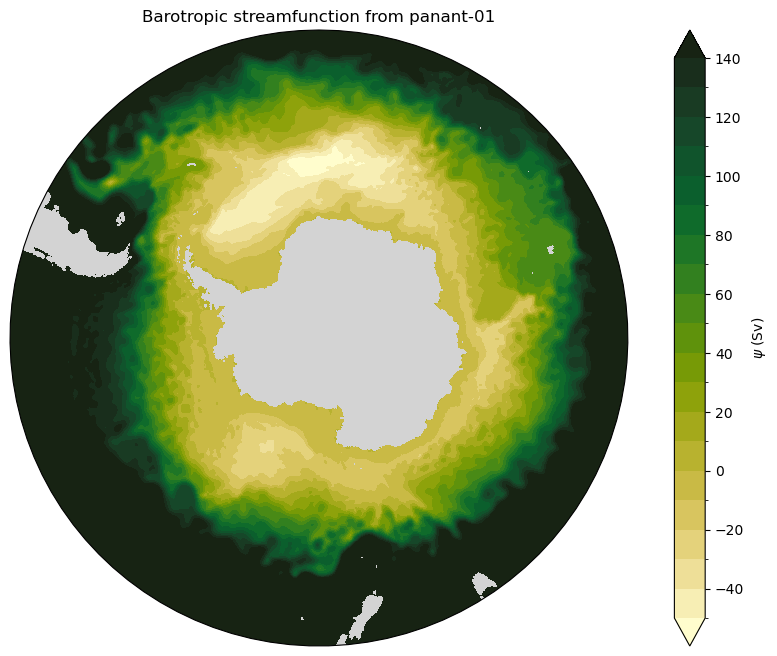

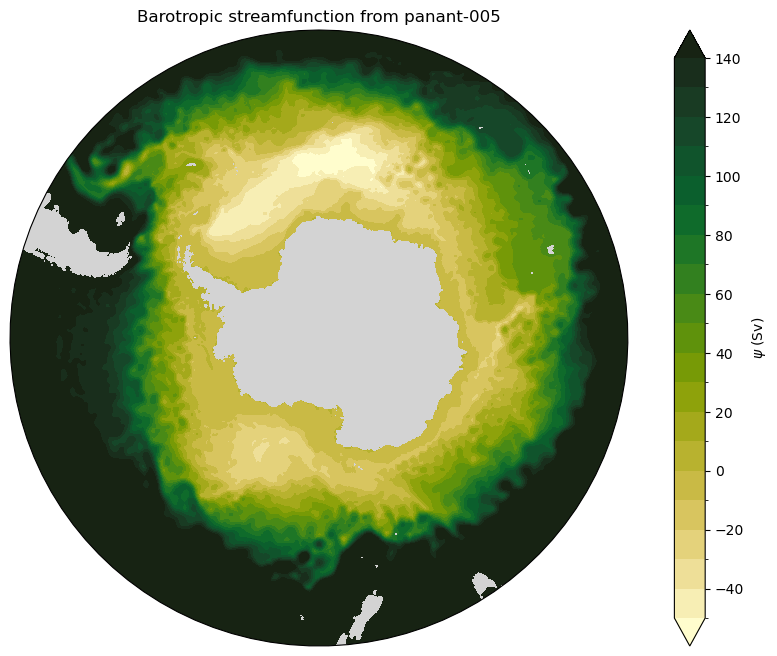

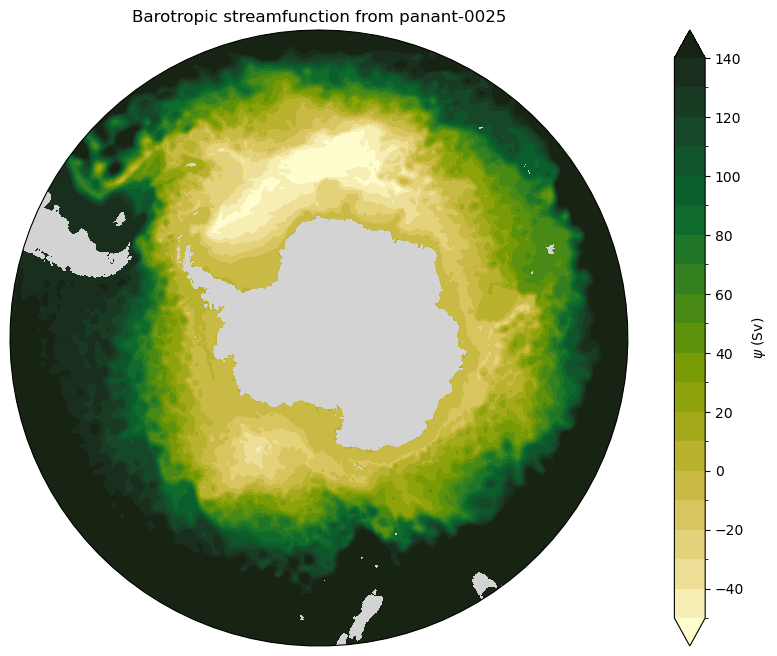

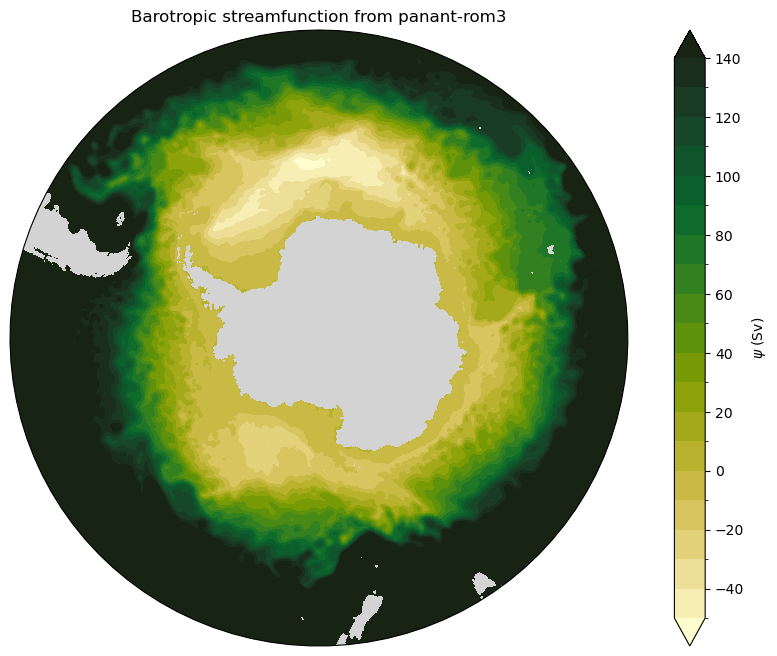

In [12]:
levels = np.arange(-50, 150, 10) # levels used in contour plots

for model in ['panant-01', 'panant-005', 'panant-0025', 'panant-rom3']:
    
    fig, ax = circumpolar_map()
    psi_mean[model].cf.plot.contourf(x = 'longitude',
                                   y = 'latitude', 
                                   transform = ccrs.PlateCarree(),
                                   levels = levels,
                                   extend = 'both',
                                   cmap = cmocean.cm.speed,
                                   cbar_kwargs = {'label': '$\psi$ (Sv)'})
    land_mask[model].plot.contourf(colors = 'lightgrey', add_colorbar = False, 
                                   zorder = 2, transform = ccrs.PlateCarree())

    plt.title('Barotropic streamfunction from ' + model)